### Random Forest is an ensemble learning algorithm that builds multiple Decision Trees and aggregates their predictions.

Key ideas:

- Uses Bootstrap Sampling (Bagging)

- Uses Feature Randomness

- Aggregates predictions using majority voting

#### Random Forest helps reduce:

- Overfitting

- Variance

### A large retail chain wants to better understand its customers in order to personalize marketing campaigns and improve conversion rates.

The company collected behavioral data from 1000 customers including:

**purchase frequency, website engagement, spending behavior, loyalty activity**

### The objective is to automatically classify customers into three segments:

Class	Segment	Meaning
- 0	Budget Buyers	Highly price-sensitive customers
- 1	Regular Customers	Moderate spending and engagement
- 2	Premium Customers	High spending and high engagement

To solve this, we build a Random Forest classification model that predicts the customer segment based on behavioral features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
retail_customer=pd.read_csv("retail_customer.csv")

In [3]:
retail_customer.head(3)

,Annual_Spending,Visit_Frequency,Avg_Order_Value,Loyalty_Score,Promotion_Response,Online_Activity,Customer_Segment
0,-1.841943,-2.678341,0.552750,-0.834298,-0.854576,-0.983396,Budget_Buyer
1,-0.261305,0.762384,0.959064,-0.768799,0.112381,-2.047392,Regular_Customer
2,-1.026478,1.370662,1.710760,-0.307538,-0.133604,1.052776,Premium_Customer


In [ ]:
retail_customer.describe()

In [ ]:
## Check Class distribition
retail_customer["Customer_Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Count")

plt.show()

In [ ]:
## Prepare for ML
X = retail_customer.drop("Customer_Segment", axis=1)
y = retail_customer["Customer_Segment"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
print(confusion_matrix(y_test, y_pred))

In [ ]:
importance = rf.feature_importances_

plt.barh(columns, importance)

plt.title("Feature Importance")

plt.show()

### Manual Gini Index Calculation (Using retail_customer Dataset)
#### Step 1: Select a Feature for Splitting

Assume the decision tree is considering a split based on:

- Annual_Spending
- Annual_Spending ≤ 0
- Annual_Spending > 0

#### Step 2: Count Class Distribution in Each Node

Assume after splitting the 1000 records we get:

Left Node (Annual_Spending ≤ 0)
| Segment          | Count |
| ---------------- | ----- |
| Budget_Buyer     | 180   |
| Regular_Customer | 90    |
| Premium_Customer | 30    |


**Total = 300**

Right Node (Annual_Spending > 0)

| Segment          | Count |
| ---------------- | ----- |
| Budget_Buyer     | 120   |
| Regular_Customer | 260   |
| Premium_Customer | 320   |

**Total = 700**
#### Step 3: Calculate Probabilities
Left Node 
- P(Budget) = 180 / 300 = 0.6
- P(Regular) = 90 / 300 = 0.3
- P(Premium) = 30 / 300 = 0.1

Right Node

- P(Budget) = 120 / 700 = 0.171
- P(Regular) = 260 / 700 = 0.371
- P(Premium) = 320 / 700 = 0.457

#### Step 4: Apply Gini Formula

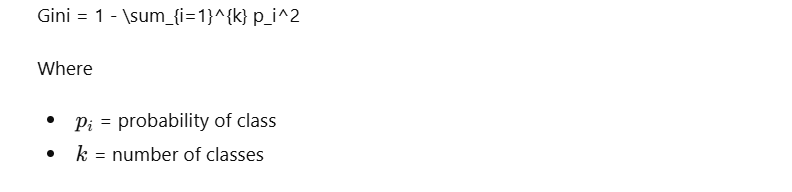


#### Step 5: Compute Gini for Left Node
Gini_left = 1 − (0.6² + 0.3² + 0.1²)

= 1 − (0.36 + 0.09 + 0.01)

= 1 − 0.46

= 0.54

#### Step 6: Compute Gini for Right Node
Gini_right = 1 − (0.171² + 0.371² + 0.457²)

= 1 − (0.029 + 0.138 + 0.209)

= 1 − 0.376

= 0.624

#### Step 7: Compute Weighted Gini for the Split

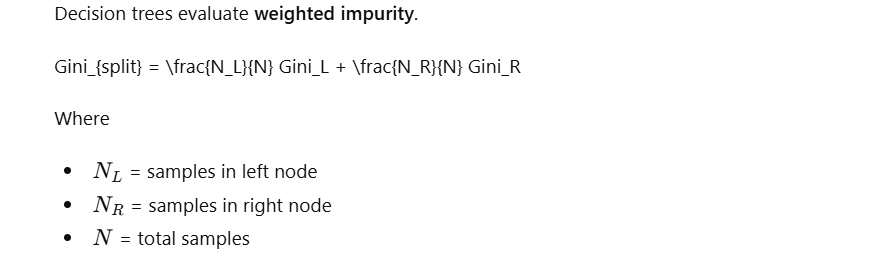

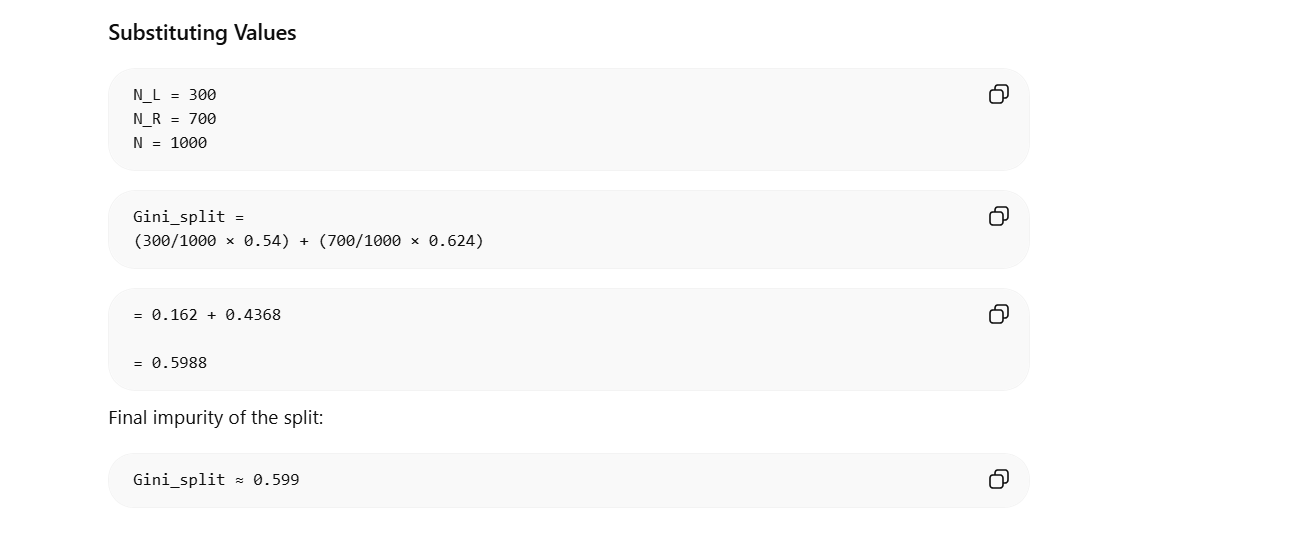

#### Step 8: Interpretation

Lower Gini means better separation.

| Gini Value | Interpretation  |
| ---------- | --------------- |
| 0          | Pure node       |
| 0–0.3      | Very good split |
| 0.3–0.6    | Moderate split  |
